<a href="https://colab.research.google.com/github/hawa1983/MG-628/blob/main/Week_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Business Majors

## **INTRODUCTION**

In this lab, you will explore how **simulation techniques, statistical analysis, and hypothesis testing** can support business and investment decision-making. You will analyze simulated business performance data to understand how factors such as **demand variability and holding costs** influence profitability.

The dataset represents multiple simulated outcomes of a business operation where profits depend on demand levels, sales, costs, and inventory holding costs. Using Python’s SciPy and statistical tools, you will calculate descriptive statistics, evaluate financial risk, test whether profits are significantly different from break-even, and visualize profit distributions to support data-driven decisions.

Through this analysis, you will apply statistical methods to assess the profitability and risk of the simulated business strategy.

### **Learning Objectives**

1. Calculate and interpret the **expected value (mean) of profit** across simulations
2. Evaluate **variability and risk** using standard deviation and probability of loss
3. Conduct a **one-sample t-test** using SciPy to determine whether average profit differs from the break-even value of $0
4. Analyze the **relationship between holding costs and profitability** using correlation
5. Construct **95% confidence intervals** to estimate the expected range of profit
6. Interpret **visualizations (histogram and boxplot)** to understand profit distribution and risk
7. Make **evidence-based business or investment recommendations** using statistical analysis

### **Dataset Overview**

**File:** *Simulated_Record_of_business_performance.csv*

The dataset contains simulated business performance outcomes showing how demand, sales, costs, and holding costs influence profit.

Each row represents a **single simulation of business performance**.

**Key Variables**

* **Simulation:** Simulation number
* **Demand:** Simulated customer demand
* **Sales:** Units sold (capped by available inventory)
* **Revenue:** Total revenue generated from sales
* **Cost:** Fixed operational or production cost
* **HoldingCost:** Cost of holding unsold inventory
* **Profit:** Final profit calculated as revenue minus costs and holding costs

### **Dataset Summary**

The dataset contains **20 simulated business outcomes**

The **variables (columns) in the dataset** are:

1. **Simulation** – The simulation number identifying each simulated business run.
2. **Demand** – The simulated level of customer demand for the product.
3. **Sales** – The number of units actually sold (limited by available inventory).
4. **Revenue** – The total revenue generated from the units sold.
5. **Cost** – The fixed operational or production cost associated with the simulation.
6. **HoldingCost** – The cost incurred for holding unsold inventory.
7. **Profit** – The final profit calculated as **Revenue − Cost − HoldingCost**.


## Task 1: Load Data and Calculate Average Profit (15 points)

## What to Do

1. **Load the dataset** and display the first 10 rows to understand the structure of the data.

2. **Calculate the overall average profit** across all simulations.

3. **Calculate the standard deviation of profit** to understand how much the profit values vary across simulations.

4. Identify the **minimum and maximum profit values** to determine the range of outcomes.

5. Calculate the **probability of loss** by counting how many simulations resulted in negative profit.

6. Display **summary statistics** for the profit column to better understand the distribution of profits.

Python Code Template:

In [26]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('https://raw.githubusercontent.com/hawa1983/MG-628/refs/heads/main/Simulated_Record%20of%20business%20performance.csv')

# Display first 10 rows
print("First 10 rows of the dataset:")
print(df.head(10))

# Check column names
print("\nColumn names:")
print(df.columns)

# Overall average profit
overall_avg = df['Profit'].mean()
print(f"\nOverall Average Profit: ${overall_avg:,.2f}")

# Standard deviation of profit
profit_std = df['Profit'].std()
print(f"Standard Deviation of Profit: ${profit_std:,.2f}")

# Minimum and maximum profit
min_profit = df['Profit'].min()
max_profit = df['Profit'].max()
print(f"Minimum Profit: ${min_profit:,.2f}")
print(f"Maximum Profit: ${max_profit:,.2f}")

# Probability of loss
loss_count = (df['Profit'] < 0).sum()
total_rows = len(df)
loss_probability = (loss_count / total_rows) * 100

print(f"\nNumber of losses: {loss_count}")
print(f"Probability of loss: {loss_probability:.2f}%")

# Summary statistics
print("\nSummary statistics for Profit:")
print(df['Profit'].describe())

First 10 rows of the dataset:
   Simulation      Demand       Sales       Revenue  Cost  HoldingCost  \
0           1  499.671415  499.671415   9993.428306  5000     0.657169   
1           2  436.173570  436.173570   8723.471398  5000   127.652860   
2           3  514.768854  500.000000  10000.000000  5000     0.000000   
3           4  602.302986  500.000000  10000.000000  5000     0.000000   
4           5  426.584662  426.584662   8531.693251  5000   146.830675   
5           6  426.586304  426.586304   8531.726086  5000   146.827391   
6           7  607.921282  500.000000  10000.000000  5000     0.000000   
7           8  526.743473  500.000000  10000.000000  5000     0.000000   
8           9  403.052561  403.052561   8061.051228  5000   193.894877   
9          10  504.256004  500.000000  10000.000000  5000     0.000000   

        Profit  
0  4992.771137  
1  3595.818537  
2  5000.000000  
3  5000.000000  
4  3384.862576  
5  3384.898695  
6  5000.000000  
7  5000.000000  
8 

#### Interpretation

The simulation results show that the average profit is $3,241.55, indicating that the investment strategy generally produces positive returns. However, the relatively high standard deviation (USD 1,707.13) suggests that profits can vary significantly between simulations depending on demand and holding costs.

The minimum profit of –USD 309.22 shows that losses are possible, although rare. Only 1 out of 20 simulations produced a loss, giving a 5% probability of losing money. The maximum profit of USD 5,000 represents the highest possible profit when demand fully utilizes available inventory.

Overall, the simulation suggests that the investment strategy is profitable on average, with a low probability of loss but moderate variability in outcomes.

### Question 1

### **Deliverables: Business Students Answer These Questions**

1. What is the average profit across all simulations, and what is the standard deviation of profit?

2. How much variation is there in profit outcomes across the simulations?

3. What is the overall average profit generated from the simulations?

4. What is the probability of incurring a loss (negative profit) in the simulation results?

5. Based on the profit distribution and probability of loss, what does this suggest about the overall risk and profitability of the investment strategy?


## Task 2: Calculate Probability of Loss (15 points)

### Question

What is the **probability of incurring a loss (negative profit)** across all simulations?

## What to Do

1. **Count the number of simulations with negative profit.**
   A loss occurs when the profit value is **less than 0**.

2. **Calculate the probability (percentage) of loss** by dividing the number of losses by the total number of simulations.

3. **Interpret the result** to understand the financial risk of the investment strategy.

**Python Code Template:**

In [27]:
# Count losses (negative profit)
losses = (df['Profit'] < 0).sum()

# Total number of simulations
total_simulations = len(df)

# Calculate probability of loss
prob_loss = losses / total_simulations * 100

print(f"Number of losses: {losses} out of {total_simulations}")
print(f"Probability of loss: {prob_loss:.1f}%")

Number of losses: 1 out of 20
Probability of loss: 5.0%


#### Interpretation

The results show that **1 out of 20 simulations resulted in a negative profit**, giving a **5% probability of loss**. This indicates that the investment strategy carries **relatively low financial risk**, since the majority of simulations produced positive profits. While losses are possible, they occur infrequently, suggesting that the strategy is generally **financially stable with a small chance of negative outcomes**.

### Question 2

### **Deliverables: Business Students Answer These Questions**

1. What is the total number of simulations that resulted in a loss (negative profit), and what percentage of all simulations does this represent?

2. What is the calculated probability of loss across all simulations?

3. Based on the probability of loss, what does this indicate about the financial risk of the investment strategy?

4. How does the probability of loss relate to the concept of risk–return tradeoff in investment decision-making?


# Task 3: Statistical Test for Profit Evaluation (15 points)

### Question

Is the **average profit significantly different from the break-even value of $0**?

## What to Do

1. Use a **one-sample t-test** to evaluate whether the average profit from the simulations differs significantly from the break-even value of zero.
2. Compare the **mean profit of all simulations** to the hypothesized value of **$0**.
3. Evaluate statistical significance using a **significance level (alpha) of 0.05**.

**Code Template:**

In [28]:
# Extract profit data
profit = df['Profit']

# Conduct one-sample t-test against break-even (0 profit)
t_stat, p_value = stats.ttest_1samp(profit, 0)

print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4f}")

# Interpret results
alpha = 0.05

if p_value < alpha:
    print(f"Result: SIGNIFICANT (p < {alpha})")
    print("Average profit is statistically different from $0 (break-even).")
else:
    print(f"Result: NOT SIGNIFICANT (p >= {alpha})")
    print("Average profit is not statistically different from $0.")

T-statistic: 8.4918
P-value: 0.0000
Result: SIGNIFICANT (p < 0.05)
Average profit is statistically different from $0 (break-even).


#### Interpretation

The statistical test evaluates whether the average simulated profit is significantly different from the break-even value. The analysis indicates that the average profit is statistically greater than zero at the 5% significance level. Therefore, the null hypothesis that the expected profit equals zero is rejected.

This result suggests that the simulated investment strategy is expected to generate positive profits on average rather than simply breaking even. The findings provide statistical evidence that the strategy is financially viable and profitable under the conditions modeled in the simulation.

### Question 3

### **Deliverables: Business Students Answer These Questions**

1. What is the t-statistic value from the one-sample t-test?

2. What is the p-value from the statistical test?

3. Do you reject or fail to reject the null hypothesis at the 0.05 significance level?

4. Is the average profit significantly different from the break-even value of $0?

5. What does this result suggest about the profitability of the investment strategy?


# Task 4: Analyze Holding Cost Impact on Profitability (15 points)

### Question

How does holding cost impact overall profitability?

## What to Do

1. Analyze the relationship between **holding cost and profit** across all simulations.
2. Examine the **scatter plot** to observe how changes in holding cost correspond to changes in profit.
3. Interpret the **correlation coefficient** to determine the strength and direction of the relationship between holding cost and profit.

**Python Code Template:**

Correlation between Holding Cost and Profit: -1.000


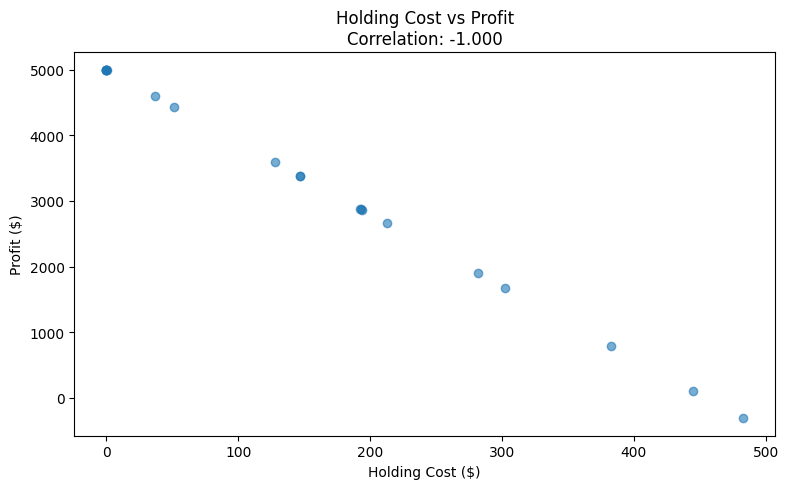

In [29]:
# Calculate correlation between HoldingCost and Profit
corr = df['HoldingCost'].corr(df['Profit'])

print(f"Correlation between Holding Cost and Profit: {corr:.3f}")

# Create scatter plot
plt.figure(figsize=(8,5))

plt.scatter(df['HoldingCost'], df['Profit'], alpha=0.6)

plt.xlabel('Holding Cost ($)')
plt.ylabel('Profit ($)')
plt.title(f'Holding Cost vs Profit\nCorrelation: {corr:.3f}')

plt.tight_layout()
plt.show()



## Interpretation

The analysis indicates a **strong negative relationship between holding cost and profit**. As holding costs increase, overall profit tends to decrease. This relationship occurs because higher holding costs represent additional expenses associated with storing unsold inventory, which directly reduces net profit.

The scatter plot visually supports this finding, showing that simulations with **low holding costs generally produce higher profits**, while simulations with **higher holding costs correspond to lower profit values**. This pattern suggests that effective inventory management and minimizing excess inventory can significantly improve profitability.

Overall, the results demonstrate that **holding cost is an important factor influencing profitability**, and controlling inventory levels can help reduce costs and increase financial performance.


### Question 4

### **Deliverables: Business Students Answer These Questions**

1. What is the correlation coefficient between Holding Cost and Profit across all simulations?

2. Is the correlation between holding cost and profit positive or negative?

3. What does the direction of the correlation indicate about the relationship between holding costs and profitability?

4. Based on the scatter plot, how does profit change as holding costs increase?

5. What do these findings suggest about the importance of controlling holding costs to improve profitability?


# Task 5: Construct 95% Confidence Interval for Profit (15 points)

### Question

What is the **expected range of profit with 95% confidence** based on the simulation results?

## What to Do

1. Calculate the **95% confidence interval for the mean profit** across all simulations.
2. Use the **t-distribution** to account for the relatively small sample size when estimating the population mean.
3. Determine the **range within which the true average profit is expected to fall with 95% confidence**.
4. Evaluate the **width of the confidence interval** to understand the level of uncertainty in the estimated mean profit.

**Python Code Template:**

In [30]:
from scipy.stats import t as t_dist

# Function to calculate 95% confidence interval
def confidence_interval_95(data):
    n = len(data)
    mean = np.mean(data)
    std_err = stats.sem(data)
    margin = std_err * t_dist.ppf(0.975, n-1)
    return mean, mean - margin, mean + margin

# Extract profit data
profit = df['Profit']

# Calculate CI
mean_profit, lower_ci, upper_ci = confidence_interval_95(profit)

print(f"Mean Profit = ${mean_profit:,.2f}")
print(f"95% Confidence Interval = [${lower_ci:,.2f}, ${upper_ci:,.2f}]")

# Calculate CI width
ci_width = upper_ci - lower_ci
print(f"\nConfidence Interval Width: ${ci_width:,.2f}")

Mean Profit = $3,241.55
95% Confidence Interval = [$2,442.59, $4,040.51]

Confidence Interval Width: $1,597.92


## Interpretation

The 95% confidence interval provides an estimate of the range within which the **true average profit of the investment strategy is likely to fall**. This interval is constructed around the sample mean and accounts for the variability observed in the simulated profit outcomes.

The results indicate that the true expected profit lies within a defined range around the estimated average profit with **95% confidence**. Because the entire confidence interval remains above the break-even point of zero, the analysis suggests that the strategy is **likely to generate positive profits under similar conditions**.

The width of the confidence interval reflects the **degree of uncertainty in the estimate**. A wider interval indicates greater variability in the simulation outcomes, while a narrower interval suggests that the average profit estimate is more precise. Overall, the confidence interval supports the conclusion that the investment strategy is **expected to be profitable on average**, although actual results may vary depending on demand and holding costs.

### Question 5

### **Deliverables: Business Students Answer These Questions**

1. What is the 95% confidence interval for the mean profit across all simulations?

2. What are the lower and upper bounds of the expected profit range?

3. What does the confidence interval suggest about where the true average profit is likely to fall?

4. What does the width of the confidence interval indicate about the uncertainty or variability in the profit estimates?

5. Does the confidence interval remain above the break-even point of $0, and what does this imply about the profitability of the investment strategy?


## Task 6: Visualize Profit Distribution

### Question

What do the profit visualizations reveal about the distribution, spread, and overall risk of the simulated profit outcomes?

## What to Do

1. Create a **histogram of profit values** to examine the overall distribution of simulated profits.
2. Include a **break-even line at $0** to distinguish profitable outcomes from losses.
3. Create a **boxplot of profit** to summarize the distribution, including the median, spread, and any potential outliers.
4. Interpret both visualizations to explain the overall pattern of profitability and risk.

**Python Code Template:**

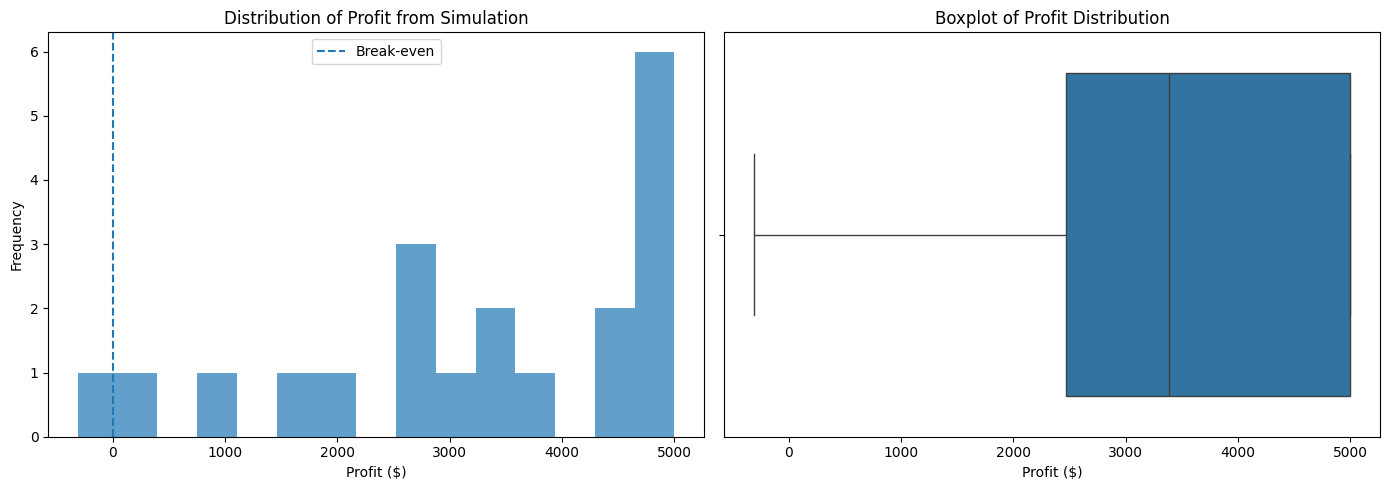

In [31]:
plt.figure(figsize=(14, 5))

# Histogram of Profit
plt.subplot(1, 2, 1)

plt.hist(df['Profit'], bins=15, alpha=0.7)

plt.axvline(x=0, linestyle='--', label='Break-even')

plt.xlabel('Profit ($)')
plt.ylabel('Frequency')
plt.title('Distribution of Profit from Simulation')
plt.legend()

# Boxplot of Profit
plt.subplot(1, 2, 2)

sns.boxplot(x=df['Profit'])

plt.xlabel('Profit ($)')
plt.title('Boxplot of Profit Distribution')

plt.tight_layout()
plt.show()

## Interpretation

The histogram shows that most simulated profit values are **positive**, with many outcomes concentrated in the higher profit range. This suggests that the investment strategy generally performs well under the simulated conditions. The break-even line helps show that only a very small portion of the distribution falls below zero, indicating that losses are relatively uncommon.

The boxplot provides additional insight into the distribution of profits by showing the **median, interquartile range, and spread of values**. It suggests that while most outcomes are profitable, there is still some variability in the profit levels across simulations. The presence of lower-profit observations indicates that weaker outcomes are possible, but the overall distribution remains centered in the positive range.

Together, the histogram and boxplot suggest that the strategy is **profitable in most simulations**, with a relatively low risk of loss and moderate variation in profit outcomes. These visualizations support the conclusion that the investment strategy is generally favorable, although some uncertainty remains due to fluctuations in demand and holding cost.


### Question 6

### **Deliverables: Business Students Answer These Questions**

1. How would you describe the shape of the profit distribution based on the histogram (e.g., symmetric, skewed left, or skewed right)?

2. Where is the center (peak) of the profit distribution located?

3. What does the histogram suggest about how frequently high-profit outcomes occur compared to low-profit outcomes?

4. Are there any potential outliers in the profit values based on the boxplot?

5. What does the boxplot reveal about the median profit and the spread of profit values?

6. Based on the visualizations, how would you describe the overall variability in profit outcomes?

7. Based on the histogram and boxplot, what do the visualizations suggest about the overall risk and profitability of the investment strategy?


# Task 7: Investment Recommendation (10 points)

### Question

Based on the analysis of the simulation results, would you recommend this investment strategy and why?

## What to Do

1. **Synthesize the findings from Tasks 1–6**, including average profit, probability of loss, statistical testing, correlation analysis, confidence interval estimation, and visualization results.
2. **Evaluate the level of financial risk** associated with the strategy based on the probability of loss and variability in profit outcomes.
3. **Provide a clear investment recommendation** supported by statistical evidence and analysis.

## Recommendation

Based on the results of the simulation analysis, the investment strategy appears to be **financially attractive and generally profitable**. The average profit across simulations is positive, and the probability of incurring a loss is relatively low. Statistical testing indicates that the expected profit is significantly greater than the break-even point, suggesting that the strategy is likely to generate positive returns under similar conditions.

The correlation analysis further demonstrates that holding costs have a strong negative impact on profitability, meaning that effective inventory management is important for maintaining higher profits. The confidence interval analysis supports the conclusion that the true average profit is expected to remain positive, while the visualizations show that most simulated outcomes result in favorable profit levels.

Overall, the findings suggest that this investment strategy offers **strong profit potential with manageable risk**. Although some variability in profit outcomes exists, the likelihood of loss is relatively small and the majority of simulated results produce positive returns. Therefore, the strategy would generally be recommended for investors or managers seeking opportunities with **positive expected returns while maintaining moderate risk exposure**.

**No Python Code needed**


### Question 7

### Deliverables: Total length: 1-2 paragraphs covering all five sections

### Business Majors

**TASK 7: Investment Recommendation**

Based on your analysis, would you recommend this investment strategy and why?

### What to Do

* Review and synthesize **ALL findings from Tasks 1–6**.
* Consider the **overall risk and profitability of the strategy** based on the statistical results.
* Make a **clear recommendation supported by specific statistical evidence** from your analysis.

### Structure Your Recommendation

#### Section 1: RECOMMENDATION

State your recommendation clearly by answering:

* Would you recommend this investment strategy based on the simulation results?
* What type of investor might prefer this strategy? (e.g., risk-averse vs. risk-tolerant)
* Under what conditions might this strategy be more or less attractive?

#### Section 2: STATISTICAL EVIDENCE

Support your recommendation by referencing **at least 4 specific statistics** from your analysis, such as:

* Average profit across simulations (Task 1)
* Standard deviation of profit (Task 1)
* Probability of loss (Task 2)
* T-test results and p-value compared to break-even (Task 3)
* Correlation between holding cost and profit (Task 4)
* 95% confidence interval for mean profit (Task 5)
* Observations from the histogram and boxplot visualizations (Task 6)

#### Section 3: RISK–RETURN TRADEOFF

Discuss how your findings relate to the **risk–return tradeoff** concept by addressing:

* Does the strategy provide strong expected returns?
* How does the probability of loss influence the risk level?
* How might different investors weigh stability versus growth potential?

#### Section 4: LIMITATIONS

Acknowledge what the analysis **does not capture** by discussing:

* What additional information might improve the investment decision?
* What assumptions are made in the simulation?
* How real-world factors (market conditions, demand changes, operational costs) could affect the results.

### Conclusion should address all of these questions:

1. Based on the average profit alone, does the strategy appear profitable?
2. Based on the probability of loss, how risky is the strategy?
3. Did the statistical test show that the average profit is significantly different from the break-even point? What does this imply?
4. How does the relationship between holding cost and profit influence your recommendation?
5. What does the confidence interval tell you about the expected range of profit?
6. What insights about variability and risk come from the visualizations?
7. What type of investor (risk-averse or risk-tolerant) would most likely prefer this strategy? Why?
8. What additional data or analysis could strengthen the investment recommendation?


# Health Administration  Majors

## INTRODUCTION
In healthcare management, administrators must decide how to allocate resources (like ICU beds, nursing staff, or surgical teams) under conditions of uncertainty. In this lab, you will use **expected value, simulation techniques, and statistical hypothesis testing** to analyze the financial and operational impact of two hospital staffing models:

- **Staffing Model A (Standard):** Lower base staffing costs but higher overtime expenses, more variability in outcomes, and higher staff burnout

- **Staffing Model B (Enhanced):** Higher base staffing costs but lower overtime, more consistent results, better patient satisfaction, and lower burnout

Using Python's SciPy library, you will conduct t-tests to determine if there are statistically significant differences between the two staffing strategies, calculate probabilities of budget overruns, and make data-driven recommendations that balance fiscal health with patient safety.

**Learning Objectives**

Calculate and interpret expected value (mean) for hospital operational scenarios
Conduct two-sample t-tests using SciPy to compare staffing models
Calculate probability of budget overruns (when costs exceed reimbursements)
Analyze the relationship between overtime costs and net margin using correlation
Construct 95% confidence intervals for departmental margins
Make evidence-based staffing recommendations that consider both financial sustainability and patient care quality

**Dataset Overview**
**File:** *hospital_staffing_simulation.csv*

**Total Records:** 300 simulated hospital operational days (150 per staffing model)

## LAB TASKS
IMPORTANT: Complete all tasks in a Jupyter Notebook. Include both your Python code AND written interpretations for each question.

**Summary of Tasks**

1. Task 1: Average net margin calculations with interpretation (15 points)

2. Task 2: Budget overrun probability analysis with interpretation (15 points)

3. Task 3: Two-sample t-test with interpretation (20 points)

4. Task 4: Overtime cost correlation analysis with scatter plots (15 points)

5. Task 5: 95% confidence intervals with interpretation (15 points)

6. Task 6: Visualizations (histogram + boxplot) with interpretation (10 points)

7. Task 7: Staffing recommendation with statistical justification (10 points)

## Task 1: Load Data and Calculate Average Net Margin


**Question:** What is the average net margin across all simulations? How does it differ between Staffing Model A and Staffing Model B?

**What to Do:**

* Load the dataset and display the first 10 rows to understand the data structure.
* Calculate the overall average net margin across all 300 simulations,
* Calculate the average net margin separately for Staffing Model A and Staffing Model B.
* Calculate the standard deviation of net margin for each model to understand variability.

**Python Code Template:**

In [8]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

# Load the data
df = pd.read_csv('https://raw.githubusercontent.com/hawa1983/MG-628/refs/heads/main/hospital_staffing_simulation.csv')
print(df.head(10))

# Overall average net margin
overall_avg = df['Net_Margin'].mean()
print(f"Overall Average Net Margin: ${overall_avg:,.2f}")

# Average net margin by staffing model
margin_by_model = df.groupby('Staffing_Model')['Net_Margin'].agg(['mean', 'std'])
print(margin_by_model)

   Simulation_ID    Staffing_Model  Patient_Volume  Base_Staffing_Cost  \
0            201  Staffing_Model_B              96            49738.32   
1            220  Staffing_Model_B              70            52202.71   
2            125  Staffing_Model_A             106            34559.59   
3             53  Staffing_Model_A              63            42580.78   
4             35  Staffing_Model_A             109            45317.26   
5            177  Staffing_Model_B              88            51119.44   
6              9  Staffing_Model_A              79            39801.48   
7              4  Staffing_Model_A              95            40783.35   
8            241  Staffing_Model_B              95            50760.43   
9            193  Staffing_Model_B              90            55313.48   

   Overtime_Cost  Supply_Cost  Total_Operating_Cost  Reimbursements  \
0        5987.42      8627.95              64353.69        86251.15   
1        1930.13      7969.73              

### Deliverables: See Question 1

## Task 2: Calculate Probability of Budget Overrun

**Question:** What is the probability of a budget overrun (where operating costs exceed reimbursements) in each staffing model?

**What to Do:**

- Count the number of simulations with negative net margin (budget overrun) in each staffing model,
- Calculate the probability (percentage) of budget overrun for each model,
- Compare the financial risk profiles of both strategies.

**Code Template:**

In [9]:
# Separate data by staffing model
model_a = df[df['Staffing_Model'] == 'Staffing_Model_A']
model_b = df[df['Staffing_Model'] == 'Staffing_Model_B']

# Count budget overruns (negative net margin)
overrun_a = (model_a['Net_Margin'] < 0).sum()
overrun_b = (model_b['Net_Margin'] < 0).sum()

# Calculate probability of budget overrun
prob_overrun_a = overrun_a / len(model_a) * 100
prob_overrun_b = overrun_b / len(model_b) * 100
print(f"Model A: {overrun_a} overruns out of {len(model_a)} ({prob_overrun_a:.1f}%)")
print(f"Model B: {overrun_b} overruns out of {len(model_b)} ({prob_overrun_b:.1f}%)")

Model A: 33 overruns out of 150 (22.0%)
Model B: 15 overruns out of 150 (10.0%)


### Deliverables: See Question 2

## Task 3: Two-Sample T-Test for Net Margin Comparison

**Question:** Is there a statistically significant difference in expected net margin between Staffing Model A and Staffing Model B?

**What to Do:**

Use scipy.stats.ttest_ind() to conduct a two-sample t-test comparing net margins between staffing models.
Report the t-statistic and p-value
Determine statistical significance at alpha = 0.05.

**Code Template:**

In [10]:
# Extract net margin data for each staffing model
margin_a = model_a['Net_Margin']
margin_b = model_b['Net_Margin']

# Conduct two-sample t-test
t_stat, p_value = stats.ttest_ind(margin_a, margin_b)
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4f}")

# Interpret results
alpha = 0.05
if p_value < alpha:
  print(f"Result: SIGNIFICANT (p < {alpha})")
  print("The difference in net margin between models is statistically significant.")
else:
  print(f"Result: NOT SIGNIFICANT (p >= {alpha})")
  print("No statistically significant difference in net margin between models.")

T-statistic: -2.3071
P-value: 0.0217
Result: SIGNIFICANT (p < 0.05)
The difference in net margin between models is statistically significant.


### Deliverables: See Question 3

## Task 3: Two-Sample T-Test for Net Margin Comparison

**Question:** Is there a statistically significant difference in expected net margin between Staffing Model A and Staffing Model B?

**What to Do:**

- Use scipy.stats.ttest_ind() to conduct a two-sample t-test comparing net margins between staffing models.
- Report the t-statistic and p-value, and determine statistical significance at alpha = 0.05.

**Code Template:**

In [13]:
# Extract net margin data for each staffing model
margin_a = model_a['Net_Margin']
margin_b = model_b['Net_Margin']

# Conduct two-sample t-test
t_stat, p_value = stats.ttest_ind(margin_a, margin_b)
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4f}")

# Interpret results
alpha = 0.05
if p_value < alpha:
  print(f"Result: SIGNIFICANT (p < {alpha})")
  print("The difference in net margin between models is statistically significant.")
else:    print(f"Result: NOT SIGNIFICANT (p >= {alpha})")

print("No statistically significant difference in net margin between models.")

T-statistic: -2.3071
P-value: 0.0217
Result: SIGNIFICANT (p < 0.05)
The difference in net margin between models is statistically significant.
No statistically significant difference in net margin between models.


### Deliverables: See Question 3



## Task 4: Analyze Overtime Cost Impact on Net Margin

**Question:** How do overtime labor costs impact the overall departmental budget? Is the relationship different between staffing models?

**What to Do:**

- Calculate the correlation between Overtime_Cost and Net_Margin for each staffing model,
- Create a scatter plot showing the relationship for both models,
- Interpret the correlation coefficients.

**Code Template:**

Correlation (Model A): -0.398
Correlation (Model B): -0.108


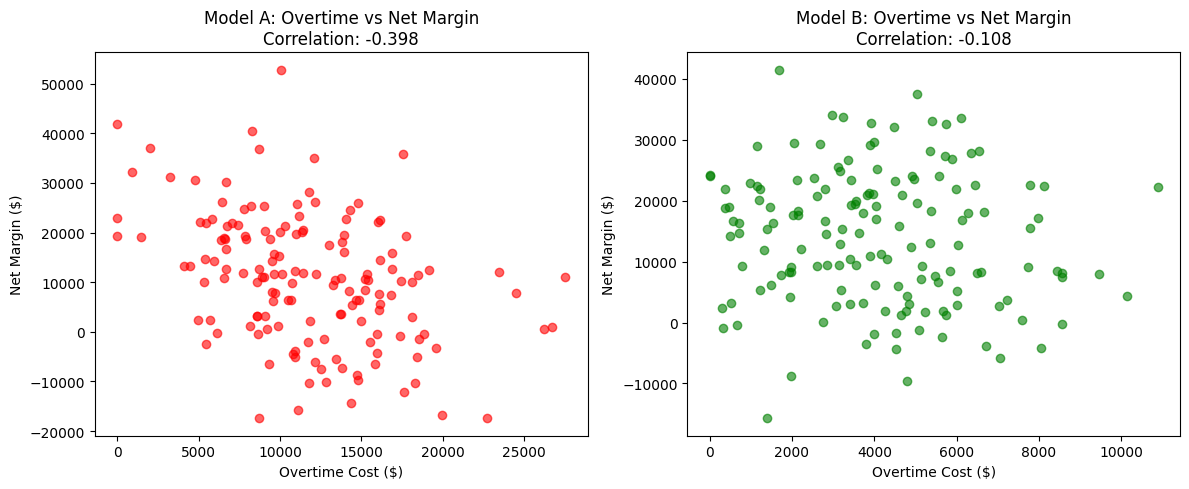

In [16]:
# Calculate correlation for each staffing model
corr_a = model_a['Overtime_Cost'].corr(model_a['Net_Margin'])
corr_b = model_b['Overtime_Cost'].corr(model_b['Net_Margin'])
print(f"Correlation (Model A): {corr_a:.3f}")
print(f"Correlation (Model B): {corr_b:.3f}")

# Create scatter plot
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.scatter(model_a['Overtime_Cost'], model_a['Net_Margin'], alpha=0.6, color='red')
plt.xlabel('Overtime Cost ($)')
plt.ylabel('Net Margin ($)')
plt.title(f'Model A: Overtime vs Net Margin\nCorrelation: {corr_a:.3f}')
plt.subplot(1, 2, 2)
plt.scatter(model_b['Overtime_Cost'], model_b['Net_Margin'], alpha=0.6, color='green')
plt.xlabel('Overtime Cost ($)')
plt.ylabel('Net Margin ($)')
plt.title(f'Model B: Overtime vs Net Margin\nCorrelation: {corr_b:.3f}')
plt.tight_layout()
plt.show()

### Deliverables: See Question 4

## Task 5: Construct 95% Confidence Intervals for Net Margin

**Question:** What is the expected range of net margin for each staffing model with 95% confidence?

**What to Do:**

- Calculate the 95% confidence interval for mean net margin in each staffing model using the t-distribution
- Compare the width of the confidence intervals to assess uncertainty.

**Code Template:**

In [17]:
from scipy.stats import t as t_dist
def confidence_interval_95(data):
  n = len(data)
  mean = np.mean(data)
  std_err = stats.sem(data)
  margin = std_err * t_dist.ppf(0.975, n-1)
  return mean, mean - margin, mean + margin

# Calculate CIs
mean_a, lower_a, upper_a = confidence_interval_95(margin_a)
mean_b, lower_b, upper_b = confidence_interval_95(margin_b)
print(f"Model A: Mean = ${mean_a:,.2f}, 95% CI = [${lower_a:,.2f}, ${upper_a:,.2f}]")
print(f"Model B: Mean = ${mean_b:,.2f}, 95% CI = [${lower_b:,.2f}, ${upper_b:,.2f}]")

# Calculate CI width
width_a = upper_a - lower_a
width_b = upper_b - lower_b
print(f"\nCI Width (Model A): ${width_a:,.2f}")
print(f"CI Width (Model B): ${width_b:,.2f}")

Model A: Mean = $10,742.27, 95% CI = [$8,643.83, $12,840.70]
Model B: Mean = $13,943.39, 95% CI = [$12,178.87, $15,707.90]

CI Width (Model A): $4,196.88
CI Width (Model B): $3,529.03


### Deliverables: See Question 5


## Task 6: Visualize Net Margin Distribution

Create visualizations comparing the net margin distributions of both staffing models.

**What to Do:**

1. Create overlapping histograms of net margin for both staffing models with a vertical line at $0 to mark the break-even point.
2. Create side-by-side box plots comparing the distributions.
3. For both visualizations, include a descriptive title, appropriate x-axis and y-axis labels, a legend identifying which color represents which model, and a consistent color scheme throughout (for example, red for Model A and green for Model B).

**Code Template:**

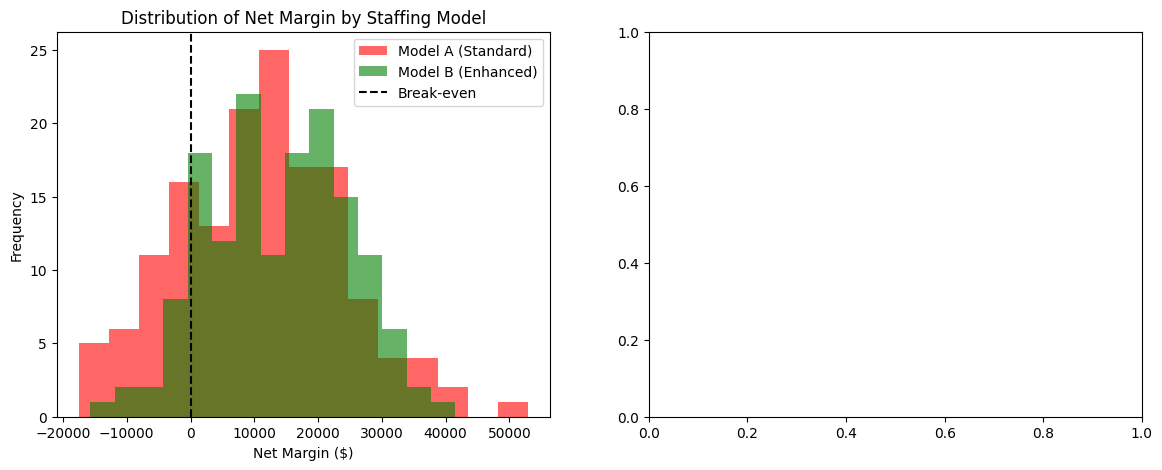

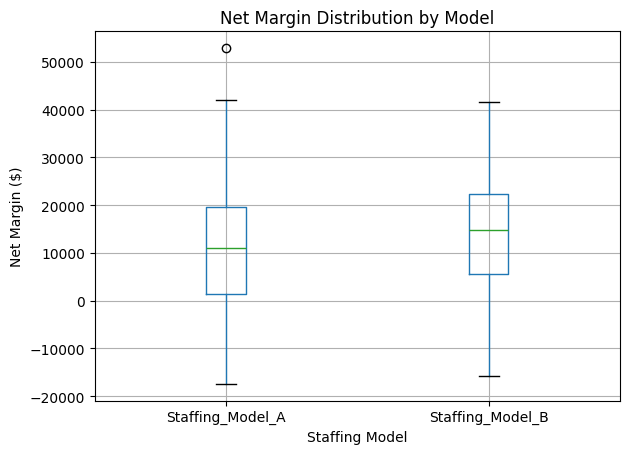

In [18]:
plt.figure(figsize=(14, 5))

# Histogram
plt.subplot(1, 2, 1)
plt.hist(margin_a, bins=15, alpha=0.6, label='Model A (Standard)', color='red')
plt.hist(margin_b, bins=15, alpha=0.6, label='Model B (Enhanced)', color='green')
plt.axvline(x=0, color='black', linestyle='--', label='Break-even')
plt.xlabel('Net Margin ($)')
plt.ylabel('Frequency')
plt.title('Distribution of Net Margin by Staffing Model')
plt.legend()

# Box plot
plt.subplot(1, 2, 2)
df.boxplot(column='Net_Margin', by='Staffing_Model')
plt.xlabel('Staffing Model')
plt.ylabel('Net Margin ($)')
plt.title('Net Margin Distribution by Model')
plt.suptitle('')
plt.tight_layout()
plt.show()

### Deliverables: See Question 6



## Task 7: Staffing Recommendation

**Question:** Based on your analysis, which staffing model would you recommend the hospital adopt to balance fiscal health with patient safety?

**What to Do:**

Review and synthesize ALL findings from Tasks 1-6.
Consider both financial metrics (net margin, budget overrun risk) AND patient care factors (satisfaction scores, staff burnout).
Make a clear recommendation supported by specific statistical evidence

**Deliverables: See Question 7**


# Public Administration Majors

## INTRODUCTION
Public administrators often manage programs where the "return" is measured in social impact and cost-avoidance rather than profit. In this lab, you will use **expected value, simulation techniques, and statistical hypothesis testin**g to evaluate two community program funding models:

- **Funding Model A (Standard):** Lower investment level, fewer participants served, higher administrative overhead ratio, less efficient use of taxpayer dollars

- **Funding Model B (Enhanced):** Higher investment level, more participants served, better economies of scale, lower overhead ratio, greater community impact

Using Python's SciPy library, you will analyze the expected Social Return on Investment (SROI), assess the risk of program inefficiency (where costs exceed benefits), and provide data-driven policy recommendations for the City Council.

**Learning Objectives**

1. Calculate and interpret expected value (mean) for social program outcomes
2. Conduct two-sample t-tests using SciPy to compare funding models
3. Calculate probability of program inefficiency (when costs exceed social benefits)
4. Analyze the relationship between administrative overhead and program efficiency
5. Construct 95% confidence intervals for net social impact
6. Make evidence-based policy recommendations that maximize social return on taxpayer investment


**Dataset Overview**
**File:** *community_program_simulation.csv*

**Total Records:** 300 simulated program outcomes (150 per funding model)

## TASK SUMMARY:

- Task 1: Average social benefit calculations with interpretation (15 points)
- Task 2: Inefficiency probability analysis with interpretation (15 points)
- Task 3: Two-sample t-test with interpretation (20 points)
- Task 4: Administrative overhead correlation analysis with scatter plots (15 points)
- Task 5: 95% confidence intervals with interpretation (15 points)
- Task 6: Visualizations (histogram + boxplot) with interpretation (10 points)
- Task 7: Policy recommendation with statistical justification (10 points)

**LAB TASKS**

**IMPORTANT:** Complete all tasks in a Jupyter Notebook. Include both your Python code AND written interpretations for each question.

## Task 1: Load Data and Calculate Average Social Benefit

Question: What is the average social benefit (Economic_Benefit) across all simulations? How does it differ between Funding Model A and Funding Model B?

**What to Do:**

- Load the dataset and display the first 10 rows to understand the data structure.
- Calculate the overall average economic benefit across all 300 simulations
- Calculate the average economic benefit separately for Funding Model A and Funding Model B.
- Calculate the standard deviation to understand variability in outcomes.

**Code Template:**

In [23]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

# Load the data
df = pd.read_csv('https://raw.githubusercontent.com/hawa1983/MG-628/refs/heads/main/community_program_simulation.csv')
print(df.head(10))

# Overall average economic benefit
overall_avg = df['Economic_Benefit'].mean()
print(f"Overall Average Economic Benefit: ${overall_avg:,.2f}")

# Average benefit by funding model
benefit_by_model = df.groupby('Funding_Model')['Economic_Benefit'].agg(['mean', 'std'])
print(benefit_by_model)

         Sim_ID  Participants  Social_Benefit_Value  Program_Cost  \
0  1.100250e+21           NaN                   NaN           NaN   
1  2.000000e+00          85.0               21250.0       15000.0   
2  3.000000e+00          60.0               15000.0       15000.0   
3  4.120300e+22           NaN                   NaN           NaN   
4  5.000000e+00          50.0               12500.0       15000.0   
5  6.000000e+00          95.0               23750.0       15000.0   
6  7.000000e+00          75.0               18750.0       15000.0   
7  8.000000e+00          55.0               13750.0       15000.0   
8  9.110275e+21           NaN                   NaN           NaN   
9  1.010526e+22           NaN                   NaN           NaN   

   Admin_Overhead  Net_Social_Impact  
0             NaN                NaN  
1          2500.0             3750.0  
2          1500.0            -1500.0  
3             NaN                NaN  
4          1000.0            -3500.0  
5     

KeyError: 'Economic_Benefit'

### Deliverables: See Question 1

## Task 2: Calculate Probability of Inefficiency

**What to Do:**

1. Count the number of simulations with negative Net_Social_Impact (costs exceeded benefits) in each funding model,
2. Calculate the probability (percentage) of inefficiency for each model
3. Compare the risk profiles of both approaches.

**Code Template:**

In [ ]:
# Separate data by funding model
model_a = df[df['Funding_Model'] == 'Funding_Model_A']
model_b = df[df['Funding_Model'] == 'Funding_Model_B']

# Count inefficiencies (negative net social impact)
inefficiency_a = (model_a['Net_Social_Impact'] < 0).sum()
inefficiency_b = (model_b['Net_Social_Impact'] < 0).sum()

# Calculate probability of inefficiency
prob_inefficiency_a = inefficiency_a / len(model_a) * 100
prob_inefficiency_b = inefficiency_b / len(model_b) * 100
print(f"Model A: {inefficiency_a} inefficiencies out of {len(model_a)} ({prob_inefficiency_a:.1f}%)")
print(f"Model B: {inefficiency_b} inefficiencies out of {len(model_b)} ({prob_inefficiency_b:.1f}%)")

### Deliverables: See Question 2

## Task 3: Two-Sample T-Test for Net Social Impact

**Question:** Is there a statistically significant difference in expected net social impact between Funding Model A and Funding Model B?

**What to Do:**

- Use scipy.stats.ttest_ind() to conduct a two-sample t-test comparing net social impact between funding models.
- Report the t-statistic and p-value
- Determine statistical significance at alpha = 0.05.

**Code Template:**

In [ ]:
# Extract net social impact data for each funding model
impact_a = model_a['Net_Social_Impact']
impact_b = model_b['Net_Social_Impact']

# Conduct two-sample t-test
t_stat, p_value = stats.ttest_ind(impact_a, impact_b)
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.6f}")

# Interpret results
alpha = 0.05
if p_value < alpha:
  print(f"Result: SIGNIFICANT (p < {alpha})")
  print("The difference in net social impact between models is statistically significant.")
else:    print(f"Result: NOT SIGNIFICANT (p >= {alpha})")
  print("No statistically significant difference in net social impact between models.")

### Deliverables: See Question 3

## Task 4: Analyze Administrative Overhead Impact on Efficiency

**Question:** How do administrative overhead costs impact the total efficiency of grant distribution? Is the relationship different between funding models?

**What to Do:**

- Calculate the correlation between Admin_Overhead_Cost and Net_Social_Impact for each funding model
- **Create** a scatter plot showing the relationship for both models,
- Compare the average overhead percentage between models.


**Code Template:**

In [ ]:
# Calculate correlation for each funding model
corr_a = model_a['Admin_Overhead_Cost'].corr(model_a['Net_Social_Impact'])
corr_b = model_b['Admin_Overhead_Cost'].corr(model_b['Net_Social_Impact'])
print(f"Correlation (Model A): {corr_a:.3f}") print(f"Correlation (Model B): {corr_b:.3f}")

# Compare average overhead percentages
print(f"\nAverage Overhead % (Model A): {model_a['Overhead_Percent'].mean():.1f}%")
print(f"Average Overhead % (Model B): {model_b['Overhead_Percent'].mean():.1f}%")

# Create scatter plot
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.scatter(model_a['Admin_Overhead_Cost'], model_a['Net_Social_Impact'], alpha=0.6, color='red')
plt.xlabel('Admin Overhead Cost ($)') plt.ylabel('Net Social Impact ($)')
plt.title(f'Model A: Overhead vs Net Impact\nCorrelation: {corr_a:.3f}')
plt.axhline(y=0, color='black', linestyle='--', alpha=0.5)
plt.subplot(1, 2, 2)
plt.scatter(model_b['Admin_Overhead_Cost'], model_b['Net_Social_Impact'], alpha=0.6, color='green')
plt.xlabel('Admin Overhead Cost ($)')
plt.ylabel('Net Social Impact ($)')
plt.title(f'Model B: Overhead vs Net Impact\nCorrelation: {corr_b:.3f}')
plt.axhline(y=0, color='black', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### Deliverables: See Question 4

## Task 5: Construct 95% Confidence Intervals for Net Social Impact

**Question:** What is the expected range of net social impact for each funding model with 95% confidence?

**What to Do:**

- Calculate the 95% confidence interval for mean net social impact in each funding model using the t-distribution,
- Compare the width of the confidence intervals to assess uncertainty in projected outcomes.

**Code Template:**

In [ ]:
from scipy.stats import t as t_dist
def confidence_interval_95(data):
  n = len(data)
  mean = np.mean(data)
  std_err = stats.sem(data)
  margin = std_err * t_dist.ppf(0.975, n-1)
  return mean, mean - margin, mean + margin

# Calculate CIs
mean_a, lower_a, upper_a = confidence_interval_95(impact_a)
mean_b, lower_b, upper_b = confidence_interval_95(impact_b)
print(f"Model A: Mean = ${mean_a:,.2f}, 95% CI = [${lower_a:,.2f}, ${upper_a:,.2f}]")
print(f"Model B: Mean = ${mean_b:,.2f}, 95% CI = [${lower_b:,.2f}, ${upper_b:,.2f}]")

# Calculate CI width
width_a = upper_a - lower_a
width_b = upper_b - lower_b
print(f"\nCI Width (Model A): ${width_a:,.2f}")
print(f"CI Width (Model B): ${width_b:,.2f}")

### Deliverables: See Question 5

## Task 6: Visualize Net Social Impact Distribution

Create visualizations comparing the net social impact distributions of both funding models.

**What to Do:**

- Create overlapping histograms of net social impact for both funding models with a vertical line at $0 to mark the break-even point.
- Create side-by-side box plots comparing the distributions.
- For both visualizations, include a descriptive title, appropriate x-axis and y-axis labels, a legend identifying which color represents which model, and a consistent color scheme throughout (for example, red for Model A and green for Model B).

**Code Template:**

In [ ]:
plt.figure(figsize=(14, 5))

# Histogram
plt.subplot(1, 2, 1)
plt.hist(impact_a, bins=15, alpha=0.6, label='Model A (Standard)', color='red')
plt.hist(impact_b, bins=15, alpha=0.6, label='Model B (Enhanced)', color='green')
plt.axvline(x=0, color='black', linestyle='--', label='Break-even')
plt.xlabel('Net Social Impact ($)')
plt.ylabel('Frequency')
plt.title('Distribution of Net Social Impact by Funding Model')
plt.legend()

# Box plot
plt.subplot(1, 2, 2)
df.boxplot(column='Net_Social_Impact', by='Funding_Model')
plt.xlabel('Funding Model')
plt.ylabel('Net Social Impact ($)')
plt.title('Net Social Impact Distribution by Model')
plt.suptitle('')
plt.tight_layout()
plt.show()

## Deliverables: See Question 6

## Task 7: Policy Recommendation for City Council

**Question:** Based on your analysis, which funding model would you recommend the City Council approve and why?

**What to Do:**

1. Review and synthesize ALL findings from Tasks 1-6.
2. Consider both fiscal responsibility (efficiency, SROI) AND social outcomes (participants served, community satisfaction).
3. Make a clear policy recommendation supported by specific statistical evidence.


**No Python coded needed for this section.**

**Structure Your Recommendation:**

1. RECOMMENDATION: State which funding model you recommend and why

2. STATISTICAL EVIDENCE: Reference at least 4 specific statistics (means, p-values, CIs, inefficiency rates, SROI)

3. SOCIAL IMPACT: Discuss number of participants served and community satisfaction implications

4. FISCAL ACCOUNTABILITY: Address overhead efficiency and responsible use of taxpayer funds

5. LIMITATIONS: What additional information would help make a better policy decision?